## Import Necessary Libraries

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from feature_engine.selection import SmartCorrelatedSelection, RecursiveFeatureElimination
from sklearn.tree import DecisionTreeRegressor
%matplotlib inline

## Loading Data

In [19]:
data = pd.read_csv(r'/media/sheikh/F262ADC762AD90C1/backup/ML/yellow-taxi-demand-analysis/3_Data/processed/d_2025_hourly_all_features.csv')
data.head()

,passenger_demand,taxi_demand,timestamp,timestamp_month,timestamp_quarter,timestamp_semester,timestamp_year,timestamp_week,timestamp_day_of_week,timestamp_day_of_month,...,passenger_demand_lag_24,taxi_demand_lag_24,passenger_demand_window_7_mean,passenger_demand_window_7_std,passenger_demand_window_7_median,taxi_demand_window_7_mean,taxi_demand_window_7_std,taxi_demand_window_7_median,passenger_demand_expanding_std,taxi_demand_expanding_std
0,1344,1051,2025-01-02 00:00:00,1,1,1,2025,1,3,2,...,9132.0,7344.0,4877.142857,1461.110699,4788.0,3405.428571,992.091370,3331.0,2455.078485,2026.716227
1,558,436,2025-01-02 01:00:00,1,1,1,2025,1,3,2,...,8996.0,8468.0,4101.285714,1706.684087,4767.0,2878.857143,1135.398671,3264.0,2499.606208,2056.576627
2,295,268,2025-01-02 02:00:00,1,1,1,2025,1,3,2,...,7364.0,7257.0,3298.285714,1879.757849,3894.0,2324.428571,1257.135614,2707.0,2576.676211,2111.283543
3,303,220,2025-01-02 03:00:00,1,1,1,2025,1,3,2,...,4904.0,4915.0,2573.714286,1926.398082,2370.0,1831.714286,1295.673019,1765.0,2652.125937,2163.145374
4,342,277,2025-01-02 04:00:00,1,1,1,2025,1,3,2,...,3015.0,2918.0,1933.000000,1809.490536,1344.0,1387.285714,1227.447177,1051.0,2711.467867,2206.412347


In [20]:
data.head().T

,0,1,2,3,4
passenger_demand,1344,558,295,303,342
taxi_demand,1051,436,268,220,277
timestamp,2025-01-02 00:00:00,2025-01-02 01:00:00,2025-01-02 02:00:00,2025-01-02 03:00:00,2025-01-02 04:00:00
timestamp_month,1,1,1,1,1
timestamp_quarter,1,1,1,1,1
timestamp_semester,1,1,1,1,1
timestamp_year,2025,2025,2025,2025,2025
timestamp_week,1,1,1,1,1
timestamp_day_of_week,3,3,3,3,3
timestamp_day_of_month,2,2,2,2,2


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6528 entries, 0 to 6527
Data columns (total 43 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   passenger_demand                  6528 non-null   int64  
 1   taxi_demand                       6528 non-null   int64  
 2   timestamp                         6528 non-null   object 
 3   timestamp_month                   6528 non-null   int64  
 4   timestamp_quarter                 6528 non-null   int64  
 5   timestamp_semester                6528 non-null   int64  
 6   timestamp_year                    6528 non-null   int64  
 7   timestamp_week                    6528 non-null   int64  
 8   timestamp_day_of_week             6528 non-null   int64  
 9   timestamp_day_of_month            6528 non-null   int64  
 10  timestamp_day_of_year             6528 non-null   int64  
 11  timestamp_weekend                 6528 non-null   int64  
 12  timest

In [22]:
df = data.copy()

## Lets's Check Correlation

In [23]:
df = data.copy()

# Only numeric columns
numeric_cols = df.select_dtypes(include='number')

corr = numeric_cols.corr()[['passenger_demand', 'taxi_demand']]
corr

,passenger_demand,taxi_demand
passenger_demand,1.000000,0.971025
taxi_demand,0.971025,1.000000
timestamp_month,-0.012029,0.043212
timestamp_quarter,-0.023666,0.015259
timestamp_semester,-0.060881,-0.035996
timestamp_year,NaN,NaN
timestamp_week,-0.012775,0.042524
timestamp_day_of_week,0.045958,0.058423
timestamp_day_of_month,0.006928,0.014137
timestamp_day_of_year,-0.011610,0.044038


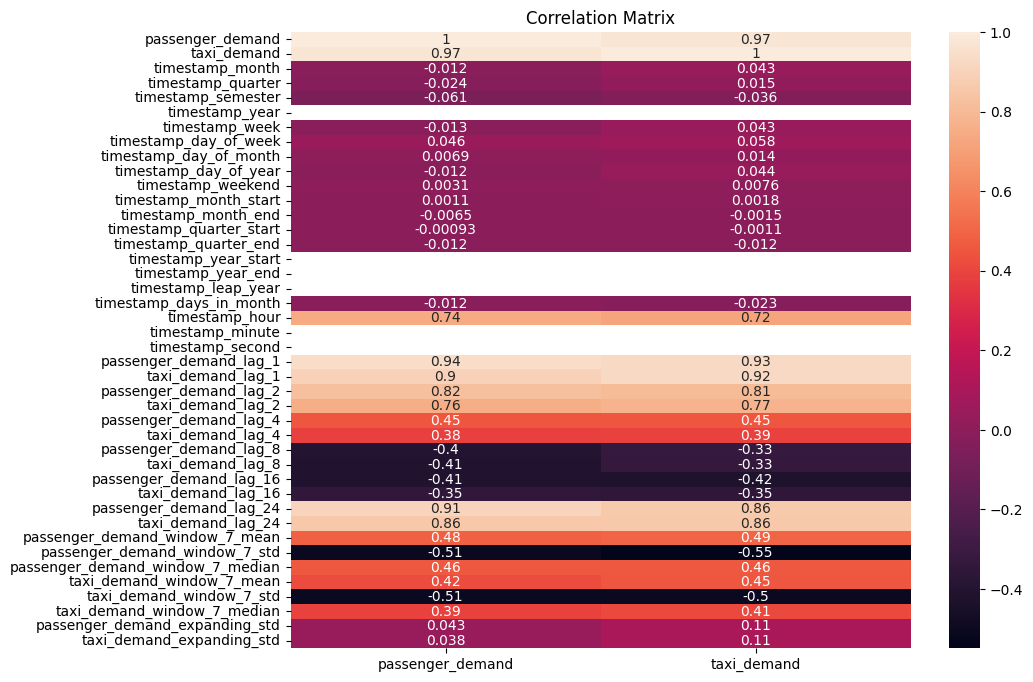

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()

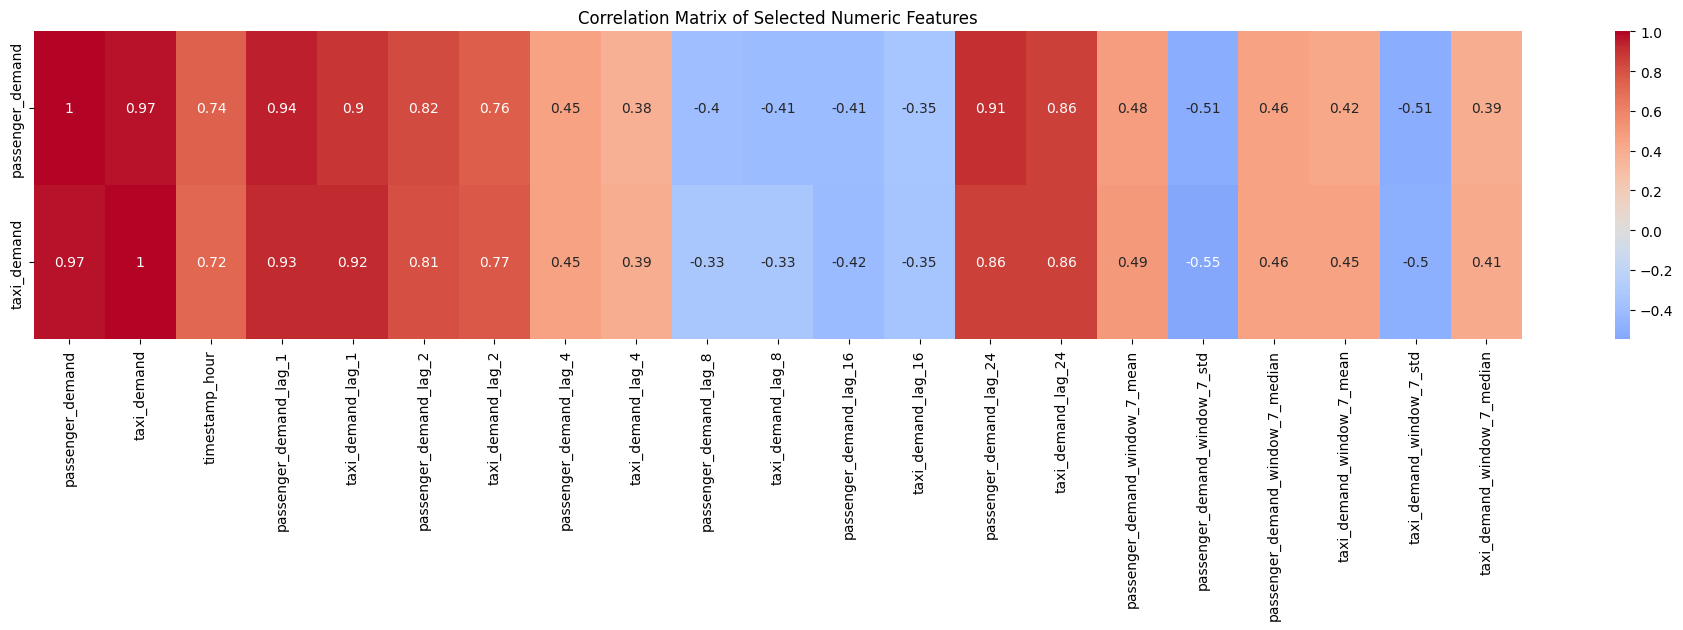

In [25]:
plt.figure(figsize=(24, 4))
sns.heatmap(corr.loc[(corr['passenger_demand'].abs() > 0.2) | (corr['taxi_demand'].abs() > 0.2)].T,
            annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Selected Numeric Features')
plt.show()

## Feature Selection

In [26]:
X = df.drop(columns=['timestamp','passenger_demand', 'taxi_demand'])
y = df['taxi_demand']

In [27]:
# SmartCorrelatedSelection?
scs = SmartCorrelatedSelection(
        variables=None, method='pearson', threshold=0.8, 
        missing_values='ignore', selection_method='variance', 
        confirm_variables=False
    )
scs.fit_transform(X).columns

Index(['timestamp_year', 'timestamp_day_of_week', 'timestamp_day_of_month',
       'timestamp_day_of_year', 'timestamp_weekend', 'timestamp_month_start',
       'timestamp_month_end', 'timestamp_quarter_start',
       'timestamp_quarter_end', 'timestamp_year_start', 'timestamp_year_end',
       'timestamp_leap_year', 'timestamp_days_in_month', 'timestamp_hour',
       'timestamp_minute', 'timestamp_second', 'passenger_demand_lag_1',
       'passenger_demand_lag_4', 'passenger_demand_lag_8',
       'passenger_demand_lag_16', 'taxi_demand_window_7_std',
       'taxi_demand_expanding_std'],
      dtype='object')

In [28]:
dt = DecisionTreeRegressor()
dt

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [29]:
rfe = RecursiveFeatureElimination(
        dt,
        scoring='r2',
        cv=3,
        threshold=0.01,
        variables=None,
        confirm_variables=False,
    )
rfe.fit_transform(X, y)

,timestamp_hour,passenger_demand_lag_1,taxi_demand_lag_1
0,0,2370.0,1765.0
1,1,1344.0,1051.0
2,2,558.0,436.0
3,3,295.0,268.0
4,4,303.0,220.0
...,...,...,...
6523,19,10642.0,10881.0
6524,20,9595.0,9779.0
6525,21,8882.0,9539.0
6526,22,9048.0,9965.0


In [30]:
def feature_selection(df):
    # feature, target split
    X = df.drop(columns=['timestamp','passenger_demand', 'taxi_demand'])
    y = df['taxi_demand']

    # smart correlated selection
    scs = SmartCorrelatedSelection(
        method='pearson', threshold=0.5,
        missing_values='ignore',
        selection_method='variance',
        confirm_variables=False,
        )
    scs_columns = set(scs.fit_transform(X).columns)

    # recursive FE
    rfe = RecursiveFeatureElimination(
        estimator=DecisionTreeRegressor(max_depth=3),
        scoring='r2',
        cv=3,
        threshold=0.01,
        variables=None,
        confirm_variables=False,
    )
    rfe_columns = rfe.fit_transform(X, y)
    scs_columns.update(rfe_columns)
    return (scs_columns)

In [31]:
best = feature_selection(df)
best

{'passenger_demand_lag_1',
 'passenger_demand_lag_8',
 'taxi_demand_expanding_std',
 'taxi_demand_lag_16',
 'timestamp_day_of_month',
 'timestamp_day_of_week',
 'timestamp_days_in_month',
 'timestamp_hour',
 'timestamp_leap_year',
 'timestamp_minute',
 'timestamp_month_end',
 'timestamp_month_start',
 'timestamp_quarter',
 'timestamp_quarter_start',
 'timestamp_second',
 'timestamp_year',
 'timestamp_year_end',
 'timestamp_year_start'}

In [32]:

df = df[['timestamp', 'taxi_demand']+list(best)]
df.head().T

,0,1,2,3,4
timestamp,2025-01-02 00:00:00,2025-01-02 01:00:00,2025-01-02 02:00:00,2025-01-02 03:00:00,2025-01-02 04:00:00
taxi_demand,1051,436,268,220,277
timestamp_quarter,1,1,1,1,1
timestamp_second,0,0,0,0,0
timestamp_hour,0,1,2,3,4
timestamp_year_end,0,0,0,0,0
passenger_demand_lag_1,2370.0,1344.0,558.0,295.0,303.0
passenger_demand_lag_8,6639.0,6775.0,6179.0,5367.0,4788.0
taxi_demand_lag_16,1116.0,1524.0,2289.0,3228.0,4087.0
timestamp_days_in_month,31,31,31,31,31


In [33]:
df.to_csv(r'/media/sheikh/F262ADC762AD90C1/backup/ML/yellow-taxi-demand-analysis/3_Data/processed/e_2025_hourly_all_selected_features.csv', index=False)

## Extract Pipeline for Selected Featured

In [34]:
def feature_selection(df):
    """
    Perform hybrid feature selection using:
    1. Correlation-based filtering (SmartCorrelatedSelection)
    2. Recursive Feature Elimination (RFE) with a Decision Tree Regressor

    Returns:
        A sorted list of selected feature names.
    """

    # Split feature + target
    X = df.drop(columns=['timestamp', 'passenger_demand', 'taxi_demand'])
    y = df['taxi_demand']

    # ----- 1. Smart Correlation Selection -----
    scs = SmartCorrelatedSelection(
        method='pearson',
        threshold=0.5,
        missing_values='ignore',
        selection_method='variance',
        confirm_variables=False
    )
    scs_selected = list(scs.fit_transform(X).columns)

    # ----- 2. Recursive Feature Elimination -----
    rfe = RecursiveFeatureElimination(
        estimator=DecisionTreeRegressor(max_depth=3),
        scoring='r2',
        cv=3,
        threshold=0.01,
        variables=None,
        confirm_variables=False
    )
    rfe_selected = list(rfe.fit_transform(X, y).columns)

    # ----- Combine + Deduplicate -----
    final_features = sorted(set(scs_selected + rfe_selected))

    return final_features


## **Q/A**

### **What is Feature Selection?**

**Feature Selection** is the process of choosing the most relevant and important features (columns) from your dataset and removing the unnecessary or less useful ones.

In simple terms:

Feature Selection decides which features to keep and which to drop before training a machine learning model.

### **Why do we need Feature Selection?**

We use Feature Selection to:

1. Improve Model Performance

    Irrelevant features add noise and reduce accuracy.

2. Reduce Overfitting

    Too many features can make the model memorize instead of generalize.

3. Faster Training & Prediction

    Fewer features = less computation = faster model.

4. Better Interpretability

    Easier to explain model decisions.

5. Handle Curse of Dimensionality

    High dimensions make data sparse and hard to learn from.

### **Feature Selection vs Feature Engineering vs PCA**

| Concept             | Purpose                          |
| ------------------- | -------------------------------- |
| Feature Engineering | Create new features              |
| Feature Selection   | Choose best existing features    |
| PCA                 | Mathematically compress features |
